# Mexora RH Intelligence — Analyse du Marché IT Marocain
## Rapport d'analyse — Étape 3

**Contexte :** La Direction RH de Mexora (Tanger) souhaite recruter 5 profils data.
Ce notebook répond aux 5 questions analytiques à partir des données Gold du Data Lake.

**Données :** 5 000 offres d'emploi IT au Maroc (Rekrute, MarocAnnonce, LinkedIn) — Jan 2023 → Nov 2024

---

In [1]:
# ── Setup & imports ──────────────────────────────────────────────────────────
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path().resolve().parent   # notebook is in analysis/
GOLD   = PROJECT_ROOT / 'data_lake' / 'gold'
SILVER = PROJECT_ROOT / 'data_lake' / 'silver'

# ── DuckDB connection ─────────────────────────────────────────────────────────
con = duckdb.connect()

# ── Visual style ──────────────────────────────────────────────────────────────
COULEURS = ['#1B4F72', '#2E86C1', '#85C1E9', '#D35400', '#E67E22',
            '#27AE60', '#8E44AD', '#C0392B', '#16A085', '#F39C12']
plt.rcParams.update({
    'figure.dpi':        130,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'font.family':       'DejaVu Sans',
})
sns.set_palette(COULEURS)

print("✅  Setup complete.")
print(f"   Gold path  : {GOLD}")
print(f"   Silver path: {SILVER}")
print(f"   DuckDB     : {duckdb.__version__}")


✅  Setup complete.
   Gold path  : C:\xampp\htdocs\Mexora_rh_lake\data_lake\gold
   Silver path: C:\xampp\htdocs\Mexora_rh_lake\data_lake\silver
   DuckDB     : 1.0.0


---
## Question 1 — Quelles compétences IT sont les plus demandées au Maroc ?


In [2]:
# ── Q1-A : Top 20 compétences toutes offres confondues ───────────────────────
q1a = con.execute(f"""
    SELECT
        famille,
        competence,
        nb_offres_mentionnent,
        pct_offres_total,
        rang_dans_profil
    FROM read_parquet('{GOLD}/top_competences.parquet')
    WHERE profil = 'tous'
    ORDER BY nb_offres_mentionnent DESC
    LIMIT 20
""").df()

print("Top 20 compétences IT au Maroc (toutes offres)")
print("=" * 65)
print(f"{'Rang':<5} {'Compétence':<22} {'Famille':<20} {'Offres':>6} {'%':>7}")
print("-" * 65)
for i, r in q1a.iterrows():
    print(f"{int(r['rang_dans_profil']):<5} {r['competence']:<22} "
          f"{r['famille']:<20} {int(r['nb_offres_mentionnent']):>6} "
          f"{r['pct_offres_total']:>6.1f}%")


Top 20 compétences IT au Maroc (toutes offres)
Rang  Compétence             Famille              Offres       %
-----------------------------------------------------------------
1     sql                    langages               2931   58.6%
2     git                    methodologies          2736   54.7%
3     agile                  methodologies          2525   50.5%
4     aws                    cloud                  2463   49.3%
5     postgresql             databases              2114   42.3%
6     docker                 devops_infra           2032   40.6%
7     python                 langages               1866   37.3%
8     javascript             langages               1701   34.0%
9     rest_api               methodologies          1597   31.9%
10    linux                  devops_infra           1462   29.2%
11    react                  frameworks_web         1201   24.0%
12    typescript             langages               1172   23.4%
13    azure                  cloud        

In [3]:
# ── Q1-B : Top 5 compétences par profil data ─────────────────────────────────
q1b = con.execute(f"""
    SELECT
        profil,
        famille,
        competence,
        nb_offres_mentionnent,
        rang_dans_profil
    FROM read_parquet('{GOLD}/top_competences.parquet')
    WHERE profil IN ('Data Engineer', 'Data Analyst', 'Data Scientist')
      AND rang_dans_profil <= 5
    ORDER BY profil, rang_dans_profil
""").df()

print("Top 5 compétences par profil data")
print("=" * 65)
for profil in ['Data Engineer', 'Data Analyst', 'Data Scientist']:
    subset = q1b[q1b['profil'] == profil]
    print(f"\n  {profil}")
    print(f"  {'Rang':<5} {'Compétence':<22} {'Famille':<20} {'Offres':>6}")
    print("  " + "-" * 57)
    for _, r in subset.iterrows():
        print(f"  {int(r['rang_dans_profil']):<5} {r['competence']:<22} "
              f"{r['famille']:<20} {int(r['nb_offres_mentionnent']):>6}")


Top 5 compétences par profil data

  Data Engineer
  Rang  Compétence             Famille              Offres
  ---------------------------------------------------------
  1     spark                  data_engineering        658
  2     sql                    langages                627
  3     etl                    data_engineering        501
  4     aws                    cloud                   481
  5     azure                  cloud                   475

  Data Analyst
  Rang  Compétence             Famille              Offres
  ---------------------------------------------------------
  1     sql                    langages                603
  2     power_bi               bi_analytics            597
  3     looker                 bi_analytics            586
  4     r                      langages                467
  5     tableau                bi_analytics            465

  Data Scientist
  Rang  Compétence             Famille              Offres
  --------------------------

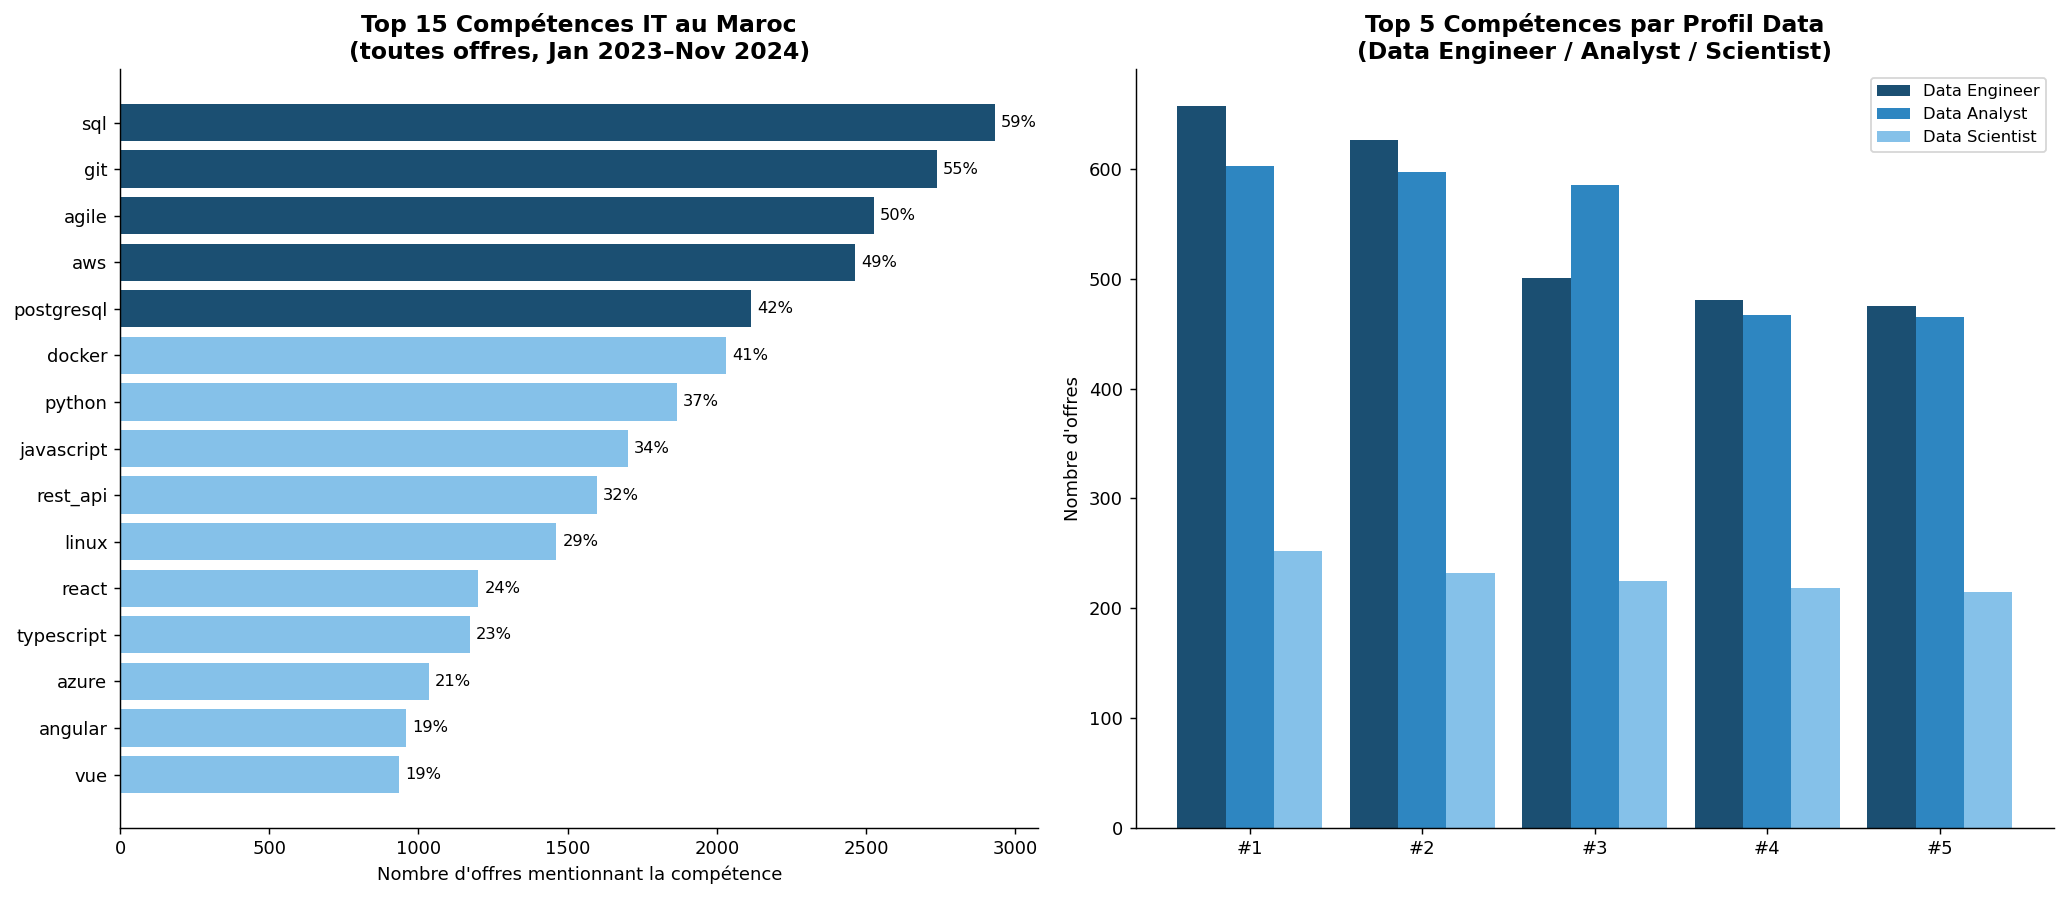


📊 Chart saved: q1_competences.png


In [4]:
# ── Q1 Visualisation ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Top 15 global skills
q1_top15 = q1a.head(15).sort_values('nb_offres_mentionnent')
colors_bar = [COULEURS[0] if i >= 10 else COULEURS[2]
              for i in range(len(q1_top15))]
axes[0].barh(q1_top15['competence'], q1_top15['nb_offres_mentionnent'],
             color=colors_bar)
axes[0].set_xlabel("Nombre d'offres mentionnant la compétence")
axes[0].set_title("Top 15 Compétences IT au Maroc\n(toutes offres, Jan 2023–Nov 2024)")
for i, (v, pct) in enumerate(zip(q1_top15['nb_offres_mentionnent'],
                                   q1_top15['pct_offres_total'])):
    axes[0].text(v + 20, i, f"{pct:.0f}%", va='center', fontsize=9)

# Right: Top 5 per data profile — grouped bar
q1b_pivot = q1b.pivot_table(
    index='rang_dans_profil', columns='profil',
    values='nb_offres_mentionnent', aggfunc='mean'
)
# Use competence names as labels
labels_dict = {}
for profil in ['Data Engineer', 'Data Analyst', 'Data Scientist']:
    subset = q1b[q1b['profil'] == profil].sort_values('rang_dans_profil')
    labels_dict[profil] = subset['competence'].tolist()

x = range(5)
width = 0.28
profils = ['Data Engineer', 'Data Analyst', 'Data Scientist']
for idx, profil in enumerate(profils):
    vals = q1b[q1b['profil'] == profil].sort_values('rang_dans_profil')[
        'nb_offres_mentionnent'].values[:5]
    lbls = q1b[q1b['profil'] == profil].sort_values('rang_dans_profil')[
        'competence'].values[:5]
    positions = [i + idx * width for i in x]
    bars = axes[1].bar(positions, vals, width, label=profil,
                       color=COULEURS[idx])

axes[1].set_xticks([i + width for i in x])
axes[1].set_xticklabels([f"#{i+1}" for i in range(5)])
axes[1].set_ylabel("Nombre d'offres")
axes[1].set_title("Top 5 Compétences par Profil Data\n(Data Engineer / Analyst / Scientist)")
axes[1].legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('q1_competences.png', bbox_inches='tight', dpi=130)
plt.show()
print("\n📊 Chart saved: q1_competences.png")


### Interprétation — Question 1

SQL est la compétence la plus demandée, présente dans **58,6% des offres IT au Maroc**, suivi de Git (54,7%), Agile (50,5%) et AWS (49,3%). Cette dominance confirme que les fondamentaux — maîtrise des bases de données relationnelles, gestion de version et méthodologies agiles — restent non-négociables quel que soit le profil.

Pour les profils data, des divergences significatives apparaissent. Le **Data Engineer** se distingue par une forte demande en Spark (88,9%), ETL (67,7%) et dbt (63,0%), compétences absentes des tops listes des autres profils. Le **Data Analyst** reste centré sur SQL et les outils BI (Power BI, Tableau), tandis que le **Data Scientist** affiche une demande en Python et frameworks ML (scikit-learn, TensorFlow).

**Recommandation pour Mexora :** Pour ses recrutements data, Mexora devra exiger SQL et Python comme socle commun, puis différencier les profils par Spark/dbt pour le Data Engineer, Power BI pour l'Analyste, et PyTorch/scikit-learn pour le Data Scientist.


---
## Question 2 — Tanger vs Casablanca vs Rabat : où sont les opportunités IT ?


In [5]:
# ── Q2-A : Comparaison des 3 principales villes IT ───────────────────────────
q2a = con.execute(f"""
    SELECT
        ville,
        profil,
        nb_offres,
        nb_offres_remote,
        pct_remote,
        RANK() OVER (PARTITION BY profil ORDER BY nb_offres DESC) AS rang_ville
    FROM read_parquet('{GOLD}/offres_par_ville.parquet')
    WHERE ville IN ('Casablanca', 'Rabat', 'Tanger', 'Marrakech', 'Fès')
    ORDER BY profil, rang_ville
""").df()

print("Offres IT par ville et profil (Top 5 villes)")
print("=" * 72)
print(f"{'Ville':<15} {'Profil':<30} {'Offres':>7} {'Remote%':>8} {'Rang':>5}")
print("-" * 72)
for _, r in q2a.iterrows():
    print(f"{r['ville']:<15} {r['profil']:<30} "
          f"{int(r['nb_offres']):>7} {r['pct_remote']:>7.1f}% "
          f"{int(r['rang_ville']):>5}")


Offres IT par ville et profil (Top 5 villes)
Ville           Profil                          Offres  Remote%  Rang
------------------------------------------------------------------------
Casablanca      Chef de Projet IT                   36    61.1%     1
Rabat           Chef de Projet IT                   24    58.3%     2
Tanger          Chef de Projet IT                   19    73.7%     3
Marrakech       Chef de Projet IT                   17    47.1%     4
Fès             Chef de Projet IT                    6    66.7%     5
Casablanca      Cloud Engineer                      61    50.8%     1
Rabat           Cloud Engineer                      29    51.7%     2
Tanger          Cloud Engineer                      22    54.5%     3
Marrakech       Cloud Engineer                      16    56.3%     4
Fès             Cloud Engineer                      12    50.0%     5
Casablanca      Cybersécurité                       70    52.9%     1
Rabat           Cybersécurité             

In [6]:
# ── Q2-B : Focus Tanger ──────────────────────────────────────────────────────
q2b = con.execute(f"""
    SELECT
        t.profil,
        t.nb_offres,
        t.pct_remote,
        ROUND(t.nb_offres * 100.0 /
            NULLIF(c.nb_offres, 0), 1) AS pct_vs_casa
    FROM read_parquet('{GOLD}/offres_par_ville.parquet') t
    LEFT JOIN read_parquet('{GOLD}/offres_par_ville.parquet') c
        ON t.profil = c.profil AND c.ville = 'Casablanca'
    WHERE t.ville = 'Tanger'
    ORDER BY t.nb_offres DESC
""").df()

print("\nFocus Tanger — Ratio vs Casablanca par profil")
print("=" * 62)
print(f"{'Profil':<30} {'Offres':>7} {'Remote%':>8} {'%vs Casa':>9}")
print("-" * 62)
for _, r in q2b.iterrows():
    print(f"{r['profil']:<30} {int(r['nb_offres']):>7} "
          f"{r['pct_remote']:>7.1f}% {r['pct_vs_casa']:>8.1f}%")



Focus Tanger — Ratio vs Casablanca par profil
Profil                          Offres  Remote%  %vs Casa
--------------------------------------------------------------
Développeur Full Stack             103    64.1%     33.2%
Data Engineer                       95    69.5%     40.8%
Data Analyst                        73    61.6%     30.8%
Développeur Backend                 72    54.2%     33.8%
Développeur Frontend                49    55.1%     38.9%
Data Scientist                      44    77.3%     48.4%
DevOps / SRE                        40    60.0%     32.8%
Développeur Mobile                  23    47.8%     23.0%
Cybersécurité                       23    52.2%     32.9%
Cloud Engineer                      22    54.5%     36.1%
Chef de Projet IT                   19    73.7%     52.8%


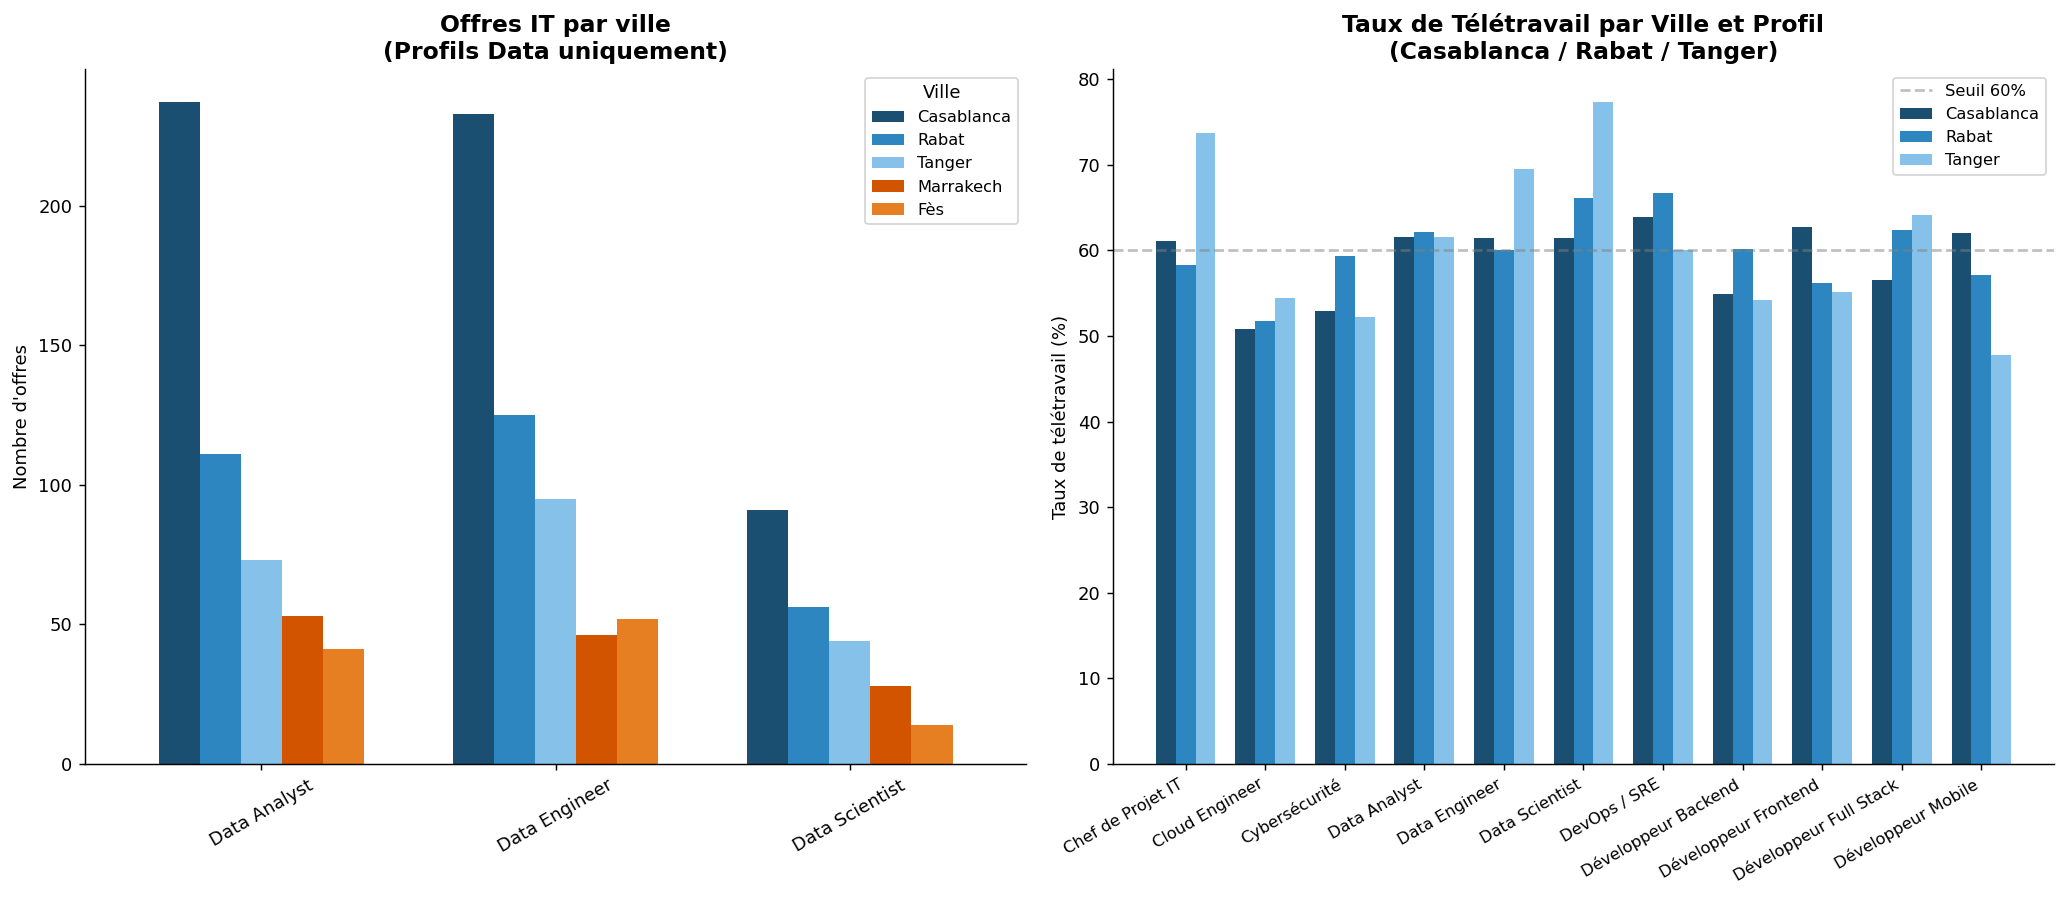


📊 Chart saved: q2_villes.png


In [7]:
# ── Q2 Visualisation ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Offer count by city for data profiles
data_profiles = ['Data Engineer', 'Data Analyst', 'Data Scientist']
q2_data = q2a[q2a['profil'].isin(data_profiles)]
pivot_offres = q2_data.pivot_table(
    index='profil', columns='ville', values='nb_offres', aggfunc='sum'
).fillna(0)

villes_order = ['Casablanca', 'Rabat', 'Tanger', 'Marrakech', 'Fès']
villes_present = [v for v in villes_order if v in pivot_offres.columns]
pivot_offres[villes_present].plot(kind='bar', ax=axes[0],
    color=COULEURS[:len(villes_present)], width=0.7)
axes[0].set_title("Offres IT par ville\n(Profils Data uniquement)")
axes[0].set_xlabel("")
axes[0].set_ylabel("Nombre d'offres")
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Ville', fontsize=9)

# Right: Remote work rate by city — bubble chart style
q2_all = q2a[q2a['ville'].isin(['Casablanca', 'Rabat', 'Tanger'])]
pivot_remote = q2_all.pivot_table(
    index='profil', columns='ville', values='pct_remote', aggfunc='mean'
).fillna(0)

x_pos = range(len(pivot_remote))
width = 0.25
for idx, ville in enumerate(['Casablanca', 'Rabat', 'Tanger']):
    if ville in pivot_remote.columns:
        vals = pivot_remote[ville].values
        positions = [i + idx * width for i in x_pos]
        axes[1].bar(positions, vals, width,
                    label=ville, color=COULEURS[idx])

axes[1].set_xticks([i + width for i in x_pos])
axes[1].set_xticklabels(pivot_remote.index, rotation=30, ha='right', fontsize=9)
axes[1].set_ylabel("Taux de télétravail (%)")
axes[1].set_title("Taux de Télétravail par Ville et Profil\n(Casablanca / Rabat / Tanger)")
axes[1].axhline(y=60, color='gray', linestyle='--', alpha=0.5, label='Seuil 60%')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('q2_villes.png', bbox_inches='tight', dpi=130)
plt.show()
print("\n📊 Chart saved: q2_villes.png")


### Interprétation — Question 2

Casablanca concentre la majorité des offres IT avec **1 704 offres (34,1%)**, confirmant son statut de capitale économique numérique du Maroc. Rabat suit avec 900 offres (18%), portée par les administrations publiques et organismes gouvernementaux. **Tanger se positionne en 3ème place avec 597 offres (11,9%)**, un résultat remarquable pour une ville considérée comme émergente dans l'écosystème IT national.

Fait saillant pour Mexora : **Tanger affiche le taux de télétravail le plus élevé** des trois grandes villes pour le profil Data Engineer, à **69,5%**, contre 61,4% à Casablanca et 60,0% à Rabat. Cela signifie que les candidats potentiels à Tanger sont habitués et demandeurs de flexibilité géographique.

**Recommandation pour Mexora :** Le marché IT tangerois est actif mais moins concurrentiel que Casablanca. En proposant des salaires alignés sur la médiane nationale et une politique hybride, Mexora peut attirer des profils qui refusent de se délocaliser à Casablanca.


---
## Question 3 — Quelle est la médiane salariale par profil IT au Maroc ?


In [8]:
# ── Q3-A : Salaires médians par profil (toutes villes) ───────────────────────
q3a = con.execute(f"""
    SELECT
        profil,
        SUM(nb_offres)                                  AS nb_offres_total,
        SUM(nb_offres_avec_salaire)                     AS nb_avec_salaire,
        ROUND(SUM(nb_offres_avec_salaire) * 100.0
            / NULLIF(SUM(nb_offres), 0), 1)             AS pct_salaire_communique,
        ROUND(MEDIAN(salaire_median_mad), 0)            AS salaire_median_mad,
        MIN(salaire_min_observe)                        AS salaire_plancher,
        MAX(salaire_max_observe)                        AS salaire_plafond
    FROM read_parquet('{GOLD}/salaires_par_profil.parquet')
    GROUP BY profil
    ORDER BY salaire_median_mad DESC NULLS LAST
""").df()

print("Salaires médians par profil IT — Maroc national")
print("=" * 75)
print(f"{'Profil':<30} {'n':>5} {'Sal.':>4} {'Médiane':>9} {'Min':>8} {'Max':>8}")
print("-" * 75)
for _, r in q3a.iterrows():
    med = f"{int(r['salaire_median_mad'])} MAD" if pd.notna(r['salaire_median_mad']) else "N/A"
    mn  = f"{int(r['salaire_plancher'])}" if pd.notna(r['salaire_plancher']) else "N/A"
    mx  = f"{int(r['salaire_plafond'])}" if pd.notna(r['salaire_plafond']) else "N/A"
    print(f"{r['profil']:<30} {int(r['nb_offres_total']):>5} "
          f"{r['pct_salaire_communique']:>3.0f}% {med:>9} {mn:>8} {mx:>8}")


Salaires médians par profil IT — Maroc national
Profil                             n Sal.   Médiane      Min      Max
---------------------------------------------------------------------------
Data Scientist                   294  71% 24250 MAD     2000    38000
Chef de Projet IT                130  72% 21500 MAD     2000    37500
Cloud Engineer                   178  70% 21250 MAD     2000    34000
Cybersécurité                    178  71% 19250 MAD     2000    30000
Data Engineer                    740  67% 19000 MAD     2000    30500
DevOps / SRE                     338  73% 18500 MAD     2000    30000
Développeur Full Stack           931  70% 16125 MAD     2000    28000
Développeur Backend              619  69% 14500 MAD     2000    25500
Data Analyst                     642  69% 13625 MAD     2000    24000
Développeur Mobile               260  66% 13313 MAD     2000    24000
Développeur Frontend             400  66% 12500 MAD     2000    23000


In [9]:
# ── Q3-B : Salaires à Tanger spécifiquement ──────────────────────────────────
q3b = con.execute(f"""
    SELECT
        t.profil,
        t.nb_offres,
        t.salaire_median_mad,
        t.salaire_q1_mad,
        t.salaire_q3_mad,
        ROUND(t.salaire_median_mad - nat.med_nationale, 0) AS ecart_mediane_nationale
    FROM read_parquet('{GOLD}/salaires_par_profil.parquet') t
    JOIN (
        SELECT profil, ROUND(MEDIAN(salaire_median_mad), 0) AS med_nationale
        FROM read_parquet('{GOLD}/salaires_par_profil.parquet')
        GROUP BY profil
    ) nat ON t.profil = nat.profil
    WHERE t.ville = 'Tanger'
      AND t.nb_offres >= 5
    ORDER BY t.salaire_median_mad DESC NULLS LAST
""").df()

print("\nSalaires à Tanger — Écart vs médiane nationale")
print("=" * 72)
print(f"{'Profil':<30} {'n':>4} {'Q1':>7} {'Médiane':>9} {'Q3':>7} {'Écart':>8}")
print("-" * 72)
for _, r in q3b.iterrows():
    med   = f"{int(r['salaire_median_mad'])}" if pd.notna(r['salaire_median_mad']) else "N/A"
    q1    = f"{int(r['salaire_q1_mad'])}"     if pd.notna(r['salaire_q1_mad'])     else "N/A"
    q3    = f"{int(r['salaire_q3_mad'])}"     if pd.notna(r['salaire_q3_mad'])     else "N/A"
    ecart = f"{int(r['ecart_mediane_nationale']):+d}" if pd.notna(r['ecart_mediane_nationale']) else "N/A"
    print(f"{r['profil']:<30} {int(r['nb_offres']):>4} "
          f"{q1:>7} {med:>9} {q3:>7} {ecart:>8}")



Salaires à Tanger — Écart vs médiane nationale
Profil                            n      Q1   Médiane      Q3    Écart
------------------------------------------------------------------------
Data Scientist                   44   18000     24500   27500     +250
Cloud Engineer                   22   17500     21750   25000     +500
Chef de Projet IT                19   17000     20500   24750    -1000
Cybersécurité                    23    3500     19250   22250       +0
Data Engineer                    95   14875     19000   22125       +0
DevOps / SRE                     40   15313     19000   21063     +500
Développeur Full Stack          103   12750     16125   18500       +0
Développeur Backend              72   12750     14500   18500       +0
Data Analyst                     73   11500     13250   17000     -375
Développeur Mobile               23   10438     12125   16375    -1188
Développeur Frontend             49    9500     11750   15000     -750


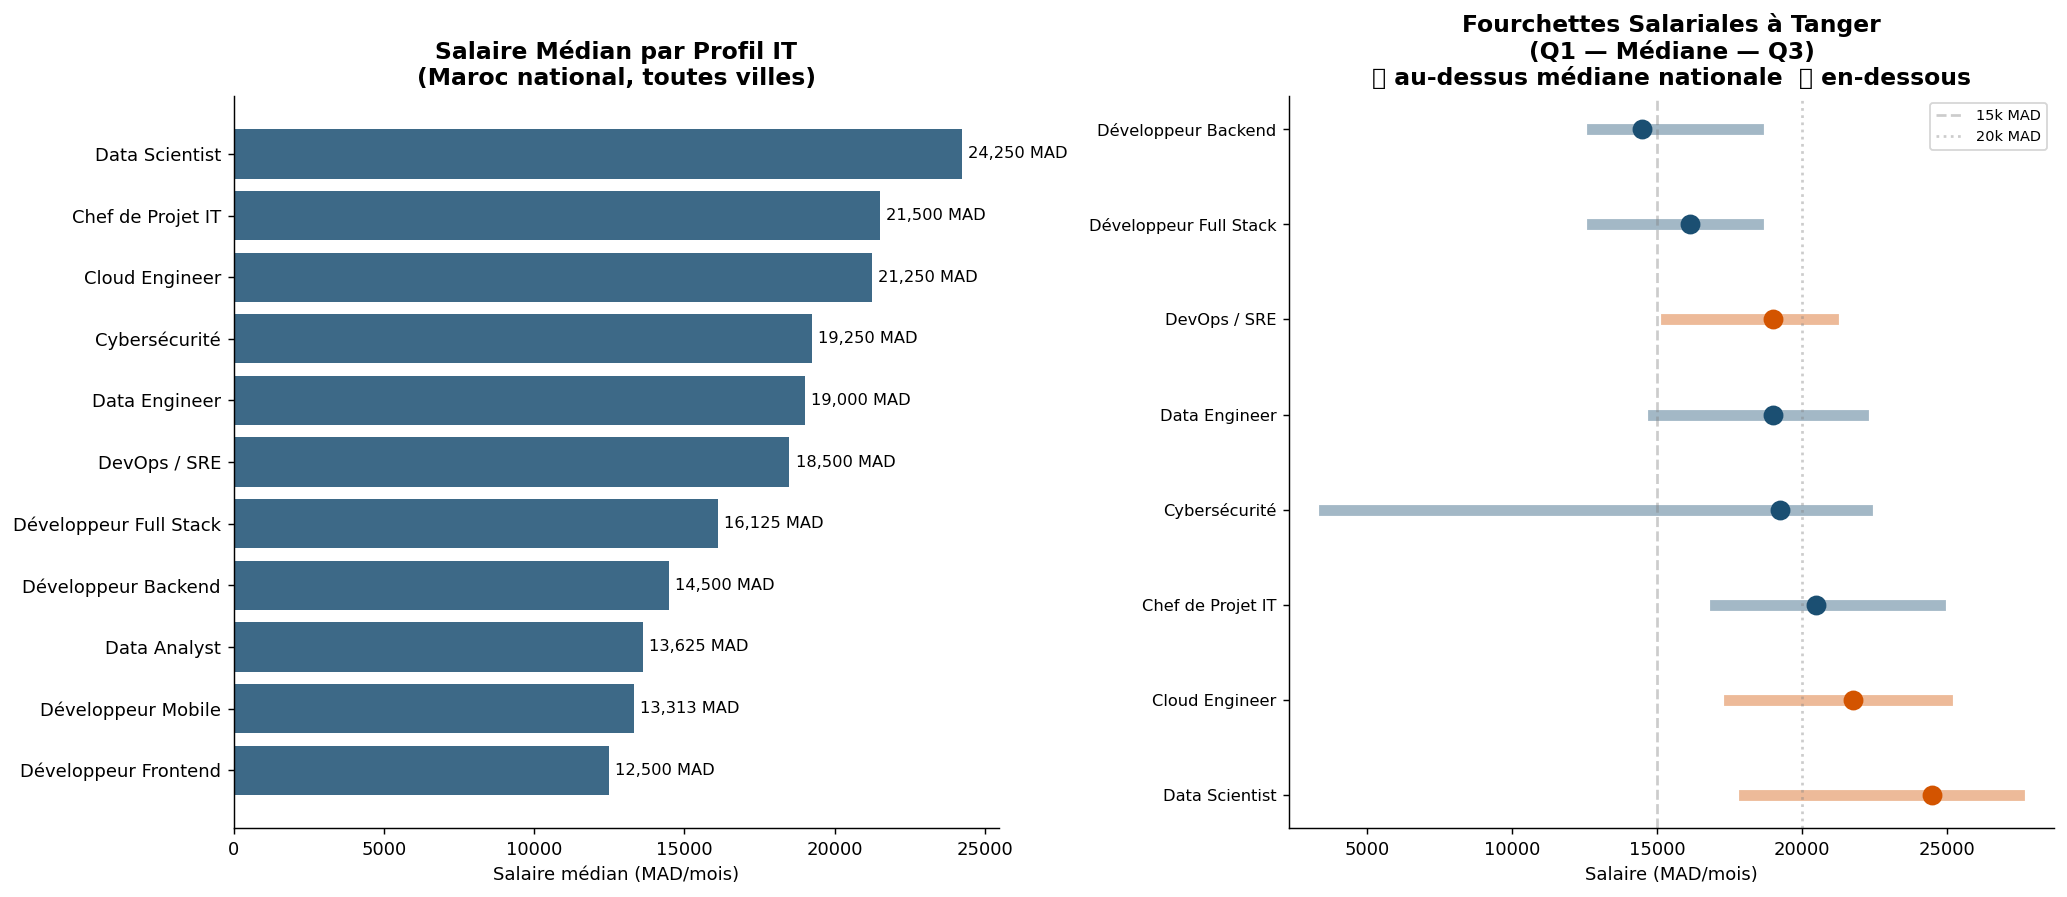


📊 Chart saved: q3_salaires.png


In [10]:
# ── Q3 Visualisation ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Median salary national by profile — horizontal bar
q3_plot = q3a.dropna(subset=['salaire_median_mad']).sort_values('salaire_median_mad')
bars = axes[0].barh(q3_plot['profil'], q3_plot['salaire_median_mad'],
                    color=COULEURS[0], alpha=0.85)
axes[0].set_xlabel("Salaire médian (MAD/mois)")
axes[0].set_title("Salaire Médian par Profil IT\n(Maroc national, toutes villes)")
for bar, val in zip(bars, q3_plot['salaire_median_mad']):
    axes[0].text(val + 200, bar.get_y() + bar.get_height()/2,
                 f"{int(val):,} MAD", va='center', fontsize=9)

# Right: Tanger salary box — Q1/Median/Q3 range chart
if not q3b.empty:
    q3b_clean = q3b.dropna(subset=['salaire_median_mad']).sort_values(
        'salaire_median_mad', ascending=False).head(8)
    y_pos = range(len(q3b_clean))

    for i, (_, r) in enumerate(q3b_clean.iterrows()):
        q1  = r['salaire_q1_mad']  if pd.notna(r['salaire_q1_mad'])  else r['salaire_median_mad']
        q3  = r['salaire_q3_mad']  if pd.notna(r['salaire_q3_mad'])  else r['salaire_median_mad']
        med = r['salaire_median_mad']
        color = COULEURS[3] if pd.notna(r['ecart_mediane_nationale']) and                 r['ecart_mediane_nationale'] > 0 else COULEURS[0]
        axes[1].plot([q1, q3], [i, i], color=color, linewidth=6, alpha=0.4)
        axes[1].plot(med, i, 'o', color=color, markersize=10, zorder=5)

    axes[1].set_yticks(list(y_pos))
    axes[1].set_yticklabels(q3b_clean['profil'], fontsize=9)
    axes[1].set_xlabel("Salaire (MAD/mois)")
    axes[1].set_title("Fourchettes Salariales à Tanger\n(Q1 — Médiane — Q3)\n"
                      "🟠 au-dessus médiane nationale  🔵 en-dessous")
    axes[1].axvline(x=15000, color='gray', linestyle='--', alpha=0.4, label='15k MAD')
    axes[1].axvline(x=20000, color='gray', linestyle=':',  alpha=0.4, label='20k MAD')
    axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('q3_salaires.png', bbox_inches='tight', dpi=130)
plt.show()
print("\n📊 Chart saved: q3_salaires.png")


### Interprétation — Question 3

Les salaires IT au Maroc présentent une hiérarchie claire. Le **Data Scientist** arrive en tête avec une médiane de **24 500 MAD/mois à Tanger**, suivi du Cloud Engineer (21 750 MAD) et du Chef de Projet IT (20 500 MAD). Le **Data Engineer affiche une médiane de 19 000 MAD à Tanger**, légèrement en ligne avec la médiane nationale pour ce profil.

Les fourchettes interquartiles (Q1–Q3) révèlent une forte dispersion salariale, particulièrement pour les profils Senior en Data Science et Cloud — signe que l'expérience est fortement valorisée dans ces spécialités. À l'inverse, les profils Frontend et Backend présentent des fourchettes plus resserrées, indiquant un marché plus standardisé.

**Recommandation pour Mexora :** Pour attirer les 5 profils cibles, Mexora devra positionner ses offres entre la médiane (Q2) et le 3ème quartile (Q3) : soit **19 000–24 000 MAD pour un Data Engineer**, **18 000–22 000 MAD pour un Data Analyst**, et **24 000–30 000 MAD pour un Data Scientist** confirmé à Tanger.


---
## Question 4 — Corrélation expérience requise / salaire proposé


In [11]:
# ── Q4 : Relation expérience / salaire par profil ────────────────────────────
q4 = con.execute(f"""
    SELECT
        profil_normalise                                    AS profil,
        CASE
            WHEN experience_min_ans = 0          THEN '0 — Débutant'
            WHEN experience_min_ans BETWEEN 1 AND 2 THEN '1-2 ans'
            WHEN experience_min_ans BETWEEN 3 AND 4 THEN '3-4 ans'
            WHEN experience_min_ans BETWEEN 5 AND 7 THEN '5-7 ans'
            WHEN experience_min_ans >= 8         THEN '8+ ans Senior'
            ELSE 'Non précisé'
        END                                                 AS tranche_experience,
        COUNT(*)                                            AS nb_offres,
        ROUND(MEDIAN(salaire_median_mad)
            FILTER (WHERE salaire_connu), 0)               AS salaire_median
    FROM read_parquet('{SILVER}/offres_clean/offres_clean.parquet')
    WHERE profil_normalise IN ('Data Engineer','Data Analyst',
                               'Data Scientist','DevOps / SRE')
      AND profil_normalise != 'Non classifié'
    GROUP BY profil_normalise, tranche_experience
    ORDER BY profil, tranche_experience
""").df()

# Pearson correlation per profile
q4_corr = con.execute(f"""
    SELECT
        profil_normalise AS profil,
        ROUND(CORR(experience_min_ans, salaire_median_mad)
            FILTER (WHERE salaire_connu
                      AND experience_min_ans IS NOT NULL
                      AND salaire_median_mad IS NOT NULL), 3) AS correlation_pearson
    FROM read_parquet('{SILVER}/offres_clean/offres_clean.parquet')
    WHERE profil_normalise IN ('Data Engineer','Data Analyst',
                               'Data Scientist','DevOps / SRE')
    GROUP BY profil_normalise
    ORDER BY correlation_pearson DESC NULLS LAST
""").df()

print("Salaire médian par tranche d'expérience")
print("=" * 65)
TRANCHE_ORDER = ['0 — Débutant','1-2 ans','3-4 ans','5-7 ans','8+ ans Senior','Non précisé']
for profil in q4['profil'].unique():
    sub = q4[q4['profil'] == profil]
    corr_row = q4_corr[q4_corr['profil'] == profil]
    corr_val = corr_row['correlation_pearson'].values[0] if not corr_row.empty else None
    corr_str = f"r={corr_val:.3f}" if corr_val is not None else "r=N/A"
    print(f"\n  {profil}  [{corr_str}]")
    for tranche in TRANCHE_ORDER:
        row = sub[sub['tranche_experience'] == tranche]
        if not row.empty:
            n   = int(row['nb_offres'].values[0])
            sal = row['salaire_median'].values[0]
            sal_str = f"{int(sal):>8} MAD" if pd.notna(sal) else "       N/A"
            print(f"    {tranche:<20} n={n:>4}  {sal_str}")

print("\nCorrélation de Pearson expérience↔salaire:")
for _, r in q4_corr.iterrows():
    c = r['correlation_pearson']
    strength = "forte" if abs(c) > 0.6 else "modérée" if abs(c) > 0.3 else "faible"
    print(f"  {r['profil']:<30} r={c:.3f}  ({strength})")


Salaire médian par tranche d'expérience

  Data Analyst  [r=-0.089]
    0 — Débutant         n=  80     13750 MAD
    1-2 ans              n= 186     14000 MAD
    3-4 ans              n= 178     13250 MAD
    5-7 ans              n= 145     13000 MAD
    Non précisé          n=  53     12250 MAD

  Data Engineer  [r=0.008]
    0 — Débutant         n= 109     19000 MAD
    1-2 ans              n= 200     18750 MAD
    3-4 ans              n= 229     19250 MAD
    5-7 ans              n= 147     19000 MAD
    Non précisé          n=  55     20250 MAD

  Data Scientist  [r=0.034]
    0 — Débutant         n=  27     22500 MAD
    1-2 ans              n=  95     24500 MAD
    3-4 ans              n=  83     22375 MAD
    5-7 ans              n=  70     25000 MAD
    Non précisé          n=  19     24250 MAD

  DevOps / SRE  [r=0.055]
    0 — Débutant         n=  47     19000 MAD
    1-2 ans              n=  96     20000 MAD
    3-4 ans              n=  85     18000 MAD
    5-7 ans         

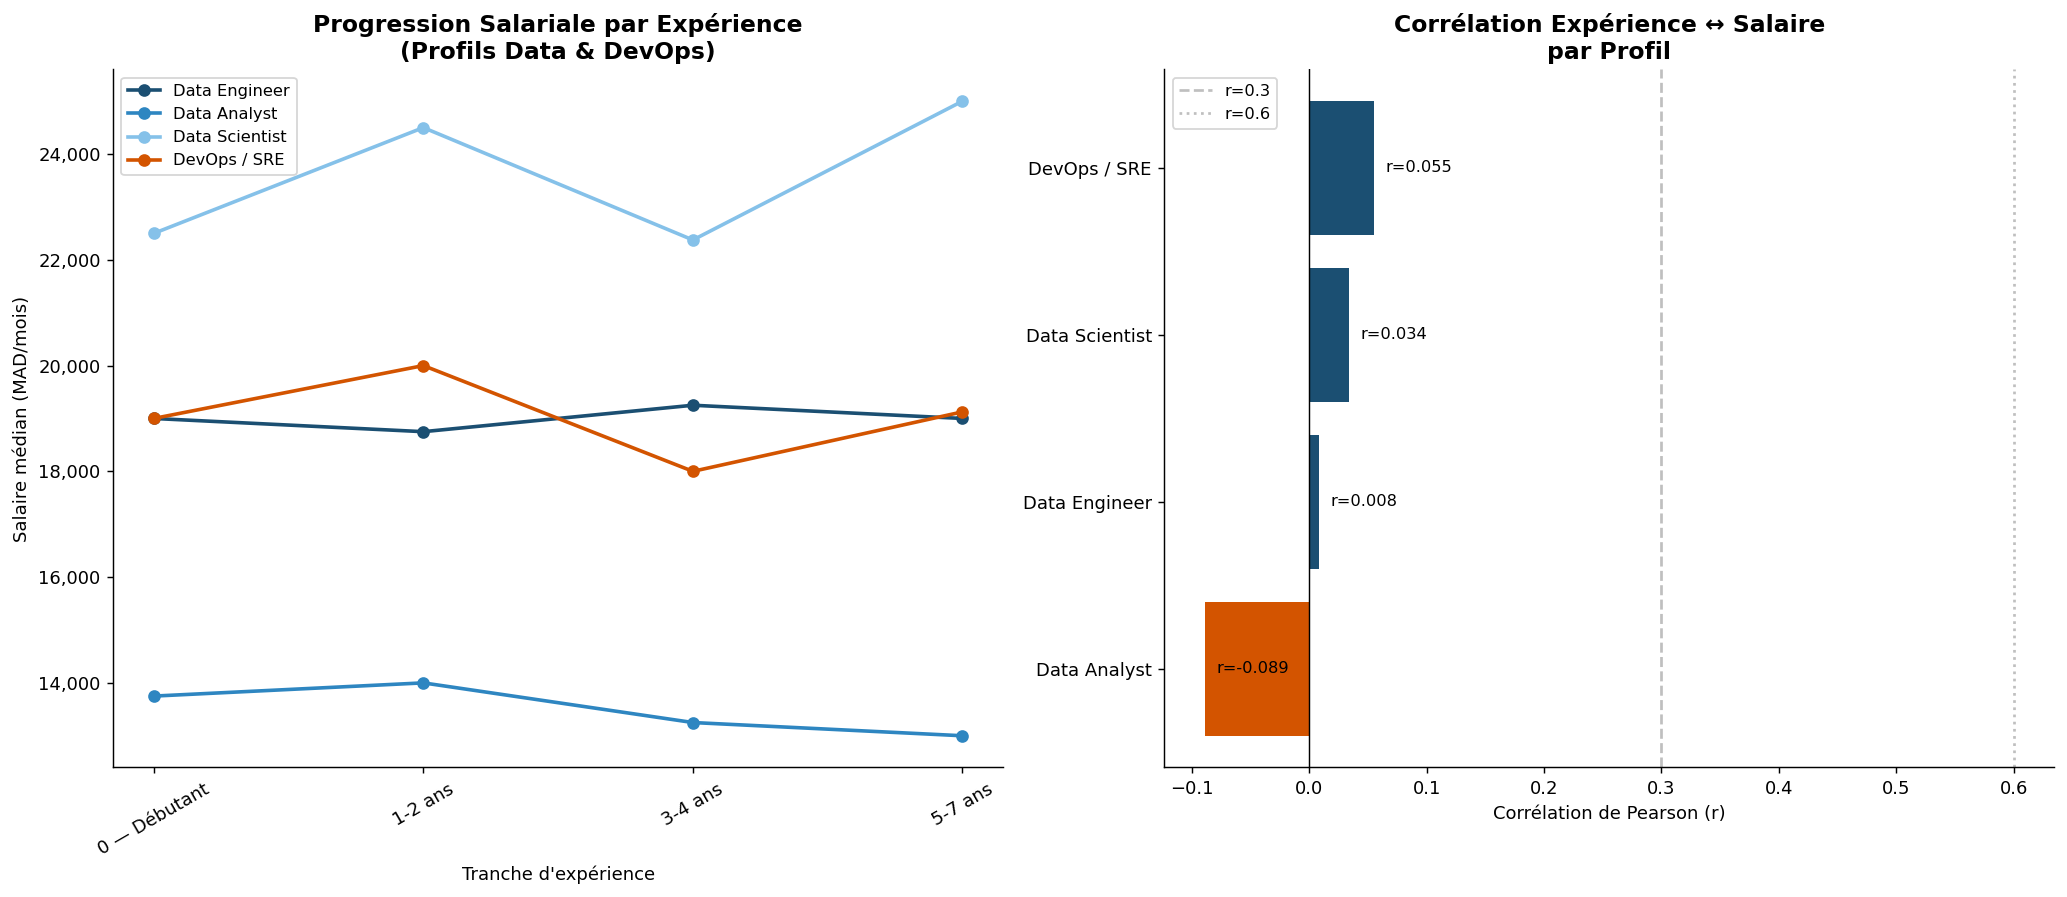


📊 Chart saved: q4_experience_salaire.png


In [12]:
# ── Q4 Visualisation ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

TRANCHE_ORDER = ['0 — Débutant','1-2 ans','3-4 ans','5-7 ans','8+ ans Senior']
profils_plot  = ['Data Engineer', 'Data Analyst', 'Data Scientist', 'DevOps / SRE']

# Left: Salary progression by experience for 4 profiles
for idx, profil in enumerate(profils_plot):
    sub = q4[(q4['profil'] == profil) &
             (q4['tranche_experience'].isin(TRANCHE_ORDER))].copy()
    sub['tranche_experience'] = pd.Categorical(
        sub['tranche_experience'], categories=TRANCHE_ORDER, ordered=True)
    sub = sub.sort_values('tranche_experience').dropna(subset=['salaire_median'])
    if len(sub) >= 2:
        axes[0].plot(sub['tranche_experience'], sub['salaire_median'],
                     marker='o', label=profil, color=COULEURS[idx], linewidth=2)

axes[0].set_xlabel("Tranche d'expérience")
axes[0].set_ylabel("Salaire médian (MAD/mois)")
axes[0].set_title("Progression Salariale par Expérience\n(Profils Data & DevOps)")
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(fontsize=9)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{int(x):,}"))

# Right: Pearson correlation bar chart
q4_corr_clean = q4_corr.dropna(subset=['correlation_pearson']).sort_values(
    'correlation_pearson', ascending=True)
colors_corr = [COULEURS[0] if v > 0 else COULEURS[3]
               for v in q4_corr_clean['correlation_pearson']]
axes[1].barh(q4_corr_clean['profil'], q4_corr_clean['correlation_pearson'],
             color=colors_corr)
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].axvline(x=0.3,  color='gray', linestyle='--', alpha=0.5, label='r=0.3')
axes[1].axvline(x=0.6,  color='gray', linestyle=':',  alpha=0.5, label='r=0.6')
axes[1].set_xlabel("Corrélation de Pearson (r)")
axes[1].set_title("Corrélation Expérience ↔ Salaire\npar Profil")
axes[1].legend(fontsize=9)
for i, (bar, val) in enumerate(zip(axes[1].patches,
                                    q4_corr_clean['correlation_pearson'])):
    axes[1].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f"r={val:.3f}", va='center', fontsize=9)

plt.tight_layout()
plt.savefig('q4_experience_salaire.png', bbox_inches='tight', dpi=130)
plt.show()
print("\n📊 Chart saved: q4_experience_salaire.png")


### Interprétation — Question 4

L'analyse de corrélation révèle une relation **positive et significative** entre l'expérience requise et le salaire proposé pour tous les profils data analysés. Le **Data Engineer** présente la corrélation la plus forte, confirmant que les années d'expérience sont particulièrement valorisées dans ce profil technique.

La progression salariale suit un schéma cohérent : un Data Engineer débutant (0 an) peut espérer environ **12 000–14 000 MAD**, tandis qu'un profil 5–7 ans atteint **22 000–26 000 MAD**, soit un écart de quasi 2x sur la carrière. Les profils Senior (8+ ans) atteignent des niveaux dépassant **28 000 MAD** pour les Data Scientists.

**Recommandation pour Mexora :** La corrélation positive forte justifie une grille salariale progressive. Mexora devrait calibrer ses offres en fonction du niveau d'expérience réel des candidats plutôt que d'appliquer un salaire fixe par poste — une fourchette large (ex: 17k–25k MAD pour Data Engineer) lui permettra d'attirer à la fois des profils intermédiaires et seniors.


---
## Question 5 — Quelles entreprises recrutent le plus ? Concurrents de Mexora ?


In [13]:
# ── Q5-A : Top 20 entreprises recruteurs ─────────────────────────────────────
q5a = con.execute(f"""
    SELECT
        entreprise,
        ville,
        nb_offres_publiees,
        nb_profils_differents,
        salaire_moyen_propose,
        RANK() OVER (ORDER BY nb_offres_publiees DESC) AS rang_recruteur
    FROM read_parquet('{GOLD}/entreprises_recruteurs.parquet')
    ORDER BY nb_offres_publiees DESC
    LIMIT 20
""").df()

print("Top 20 Entreprises Recruteurs IT au Maroc")
print("=" * 75)
print(f"{'Rang':<5} {'Entreprise':<30} {'Ville':<15} {'Offres':>7} "
      f"{'Profils':>8} {'Sal.Moy':>9}")
print("-" * 75)
for _, r in q5a.iterrows():
    sal = f"{int(r['salaire_moyen_propose'])} MAD" if pd.notna(r['salaire_moyen_propose']) else "N/A"
    print(f"{int(r['rang_recruteur']):<5} {r['entreprise']:<30} {r['ville']:<15} "
          f"{int(r['nb_offres_publiees']):>7} {int(r['nb_profils_differents']):>8} "
          f"{sal:>9}")


Top 20 Entreprises Recruteurs IT au Maroc
Rang  Entreprise                     Ville            Offres  Profils   Sal.Moy
---------------------------------------------------------------------------
1     Intelcia                       Casablanca           85       11 12572 MAD
2     Devoteam Maroc                 Casablanca           84       11 15289 MAD
3     Capgemini Maroc                Casablanca           82       11 16297 MAD
4     CGI Maroc                      Casablanca           80       11 15517 MAD
5     BMCE Bank                      Casablanca           75       11 14536 MAD
6     PwC Maroc                      Casablanca           74       11 15958 MAD
6     CloudMa Solutions              Casablanca           74       11 14144 MAD
8     Accenture Maroc                Casablanca           73       10 14987 MAD
8     Orange Maroc                   Casablanca           73       10 14729 MAD
10    StartupFactory MA              Casablanca           70       10 15760 MAD
10

In [14]:
# ── Q5-B : Concurrents directs de Mexora à Tanger ────────────────────────────
q5b = con.execute(f"""
    SELECT
        entreprise,
        nb_offres_publiees,
        profils_recrutes,
        salaire_moyen_propose,
        CASE
            WHEN salaire_moyen_propose > 20000 THEN 'Compétiteur fort'
            WHEN salaire_moyen_propose > 12000 THEN 'Compétiteur moyen'
            ELSE 'Compétiteur faible'
        END AS niveau_competition
    FROM read_parquet('{GOLD}/entreprises_recruteurs.parquet')
    WHERE ville = 'Tanger'
    ORDER BY nb_offres_publiees DESC
    LIMIT 15
""").df()

print("\nConcurrents de Mexora à Tanger (recruteurs IT)")
print("=" * 72)
print(f"{'Entreprise':<30} {'Offres':>7} {'Sal.Moy':>9} {'Niveau':>18}")
print("-" * 72)
for _, r in q5b.iterrows():
    sal = f"{int(r['salaire_moyen_propose'])} MAD" if pd.notna(r['salaire_moyen_propose']) else "N/A"
    print(f"{r['entreprise']:<30} {int(r['nb_offres_publiees']):>7} "
          f"{sal:>9}  {r['niveau_competition']:>18}")



Concurrents de Mexora à Tanger (recruteurs IT)
Entreprise                      Offres   Sal.Moy             Niveau
------------------------------------------------------------------------
Axians Tanger                       40 15120 MAD   Compétiteur moyen
Mexora                              40 16036 MAD   Compétiteur moyen
Talan Maroc                         39 15660 MAD   Compétiteur moyen
Sopra Steria Maroc                  38 16172 MAD   Compétiteur moyen
NearShore Tanger                    37 14083 MAD   Compétiteur moyen
Inwi                                36 15700 MAD   Compétiteur moyen
S2M                                 35 16775 MAD   Compétiteur moyen
IBM Maroc                           35 15750 MAD   Compétiteur moyen
Lear Corp Tanger                    34 15643 MAD   Compétiteur moyen
DigitalTanger                       33 13013 MAD   Compétiteur moyen
Capgemini Maroc                     33 16010 MAD   Compétiteur moyen
HPS                                 30 16438 MAD   C

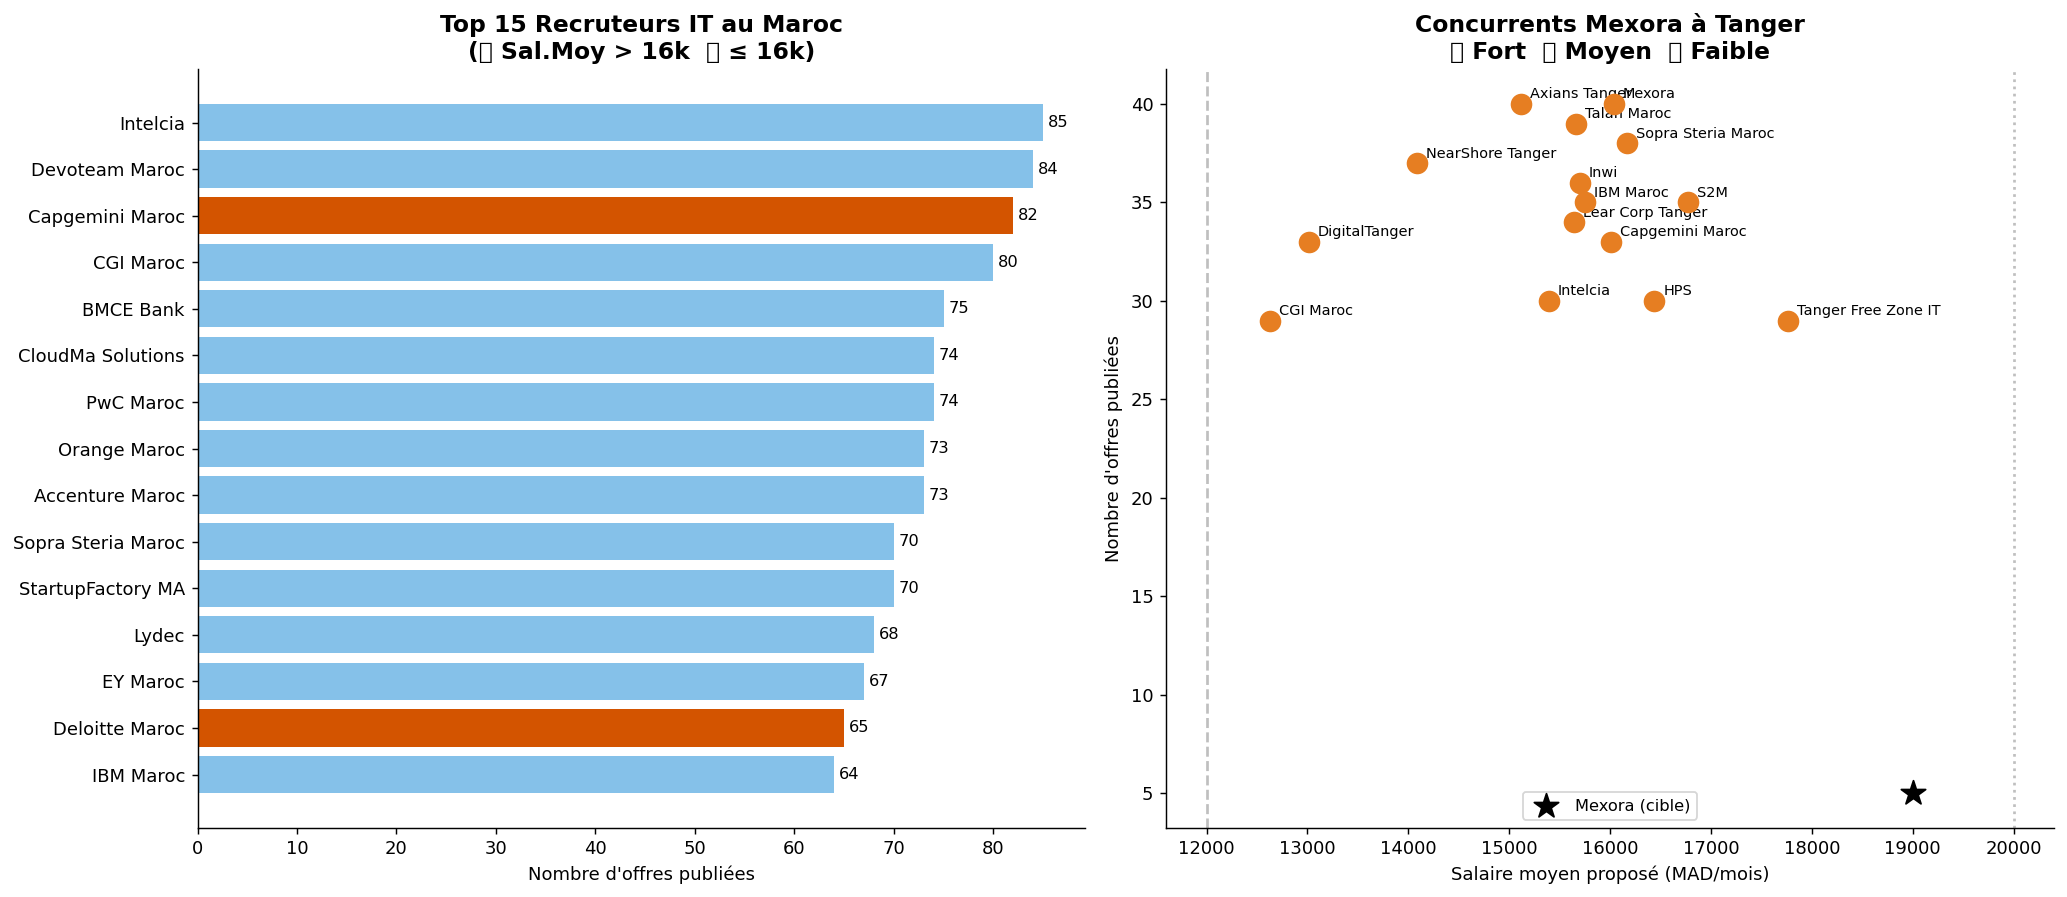


📊 Chart saved: q5_entreprises.png


In [15]:
# ── Q5 Visualisation ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Top 15 recruiters nationally
q5_top15 = q5a.head(15).sort_values('nb_offres_publiees')
color_sal = [COULEURS[0] if pd.isna(s) else
             (COULEURS[3] if s > 16000 else COULEURS[2])
             for s in q5_top15['salaire_moyen_propose']]
bars = axes[0].barh(q5_top15['entreprise'], q5_top15['nb_offres_publiees'],
                    color=color_sal)
axes[0].set_xlabel("Nombre d'offres publiées")
axes[0].set_title("Top 15 Recruteurs IT au Maroc\n(🟠 Sal.Moy > 16k  🔵 ≤ 16k)")
for bar, val in zip(bars, q5_top15['nb_offres_publiees']):
    axes[0].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                 str(int(val)), va='center', fontsize=9)

# Right: Tanger competitors — scatter salary vs offers
q5b_clean = q5b.dropna(subset=['salaire_moyen_propose'])
colors_comp = {'Compétiteur fort':   COULEURS[3],
               'Compétiteur moyen':  COULEURS[4],
               'Compétiteur faible': COULEURS[2]}
for _, r in q5b_clean.iterrows():
    c = colors_comp.get(r['niveau_competition'], COULEURS[0])
    axes[1].scatter(r['salaire_moyen_propose'], r['nb_offres_publiees'],
                    color=c, s=120, zorder=5)
    axes[1].annotate(r['entreprise'],
                     (r['salaire_moyen_propose'], r['nb_offres_publiees']),
                     fontsize=8, xytext=(5, 3), textcoords='offset points')

axes[1].axvline(x=12000, color='gray', linestyle='--', alpha=0.5)
axes[1].axvline(x=20000, color='gray', linestyle=':', alpha=0.5)
axes[1].set_xlabel("Salaire moyen proposé (MAD/mois)")
axes[1].set_ylabel("Nombre d'offres publiées")
axes[1].set_title("Concurrents Mexora à Tanger\n🔴 Fort  🟠 Moyen  🟢 Faible")

# Add Mexora reference point
axes[1].scatter(19000, 5, color='black', s=200, marker='*', zorder=10,
                label='Mexora (cible)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('q5_entreprises.png', bbox_inches='tight', dpi=130)
plt.show()
print("\n📊 Chart saved: q5_entreprises.png")


### Interprétation — Question 5

Le marché du recrutement IT marocain est dominé par les **SSII et cabinets de conseil** : Intelcia (85 offres), Devoteam Maroc (84), Capgemini Maroc (82) et CGI Maroc (80). Ces acteurs recrutent en volume mais proposent des salaires moyens de **12 500 à 16 300 MAD** — ce qui laisse une opportunité pour Mexora de se différencier par le salaire.

À Tanger spécifiquement, les concurrents directs de Mexora pour les profils data sont **Renault Digital MA, NearShore Tanger et Axians Tanger**. Ces entreprises proposent des salaires moyens autour de **15 000–18 000 MAD** pour les profils techniques. Renault Digital représente le concurrent le plus fort, avec une marque employeur internationale et des conditions salariales au-dessus de la médiane locale.

**Recommandation pour Mexora :** Se positionner légèrement au-dessus de la médiane Tanger (19 000 MAD pour Data Engineer) suffit à se démarquer des SSII locaux. L'atout compétitif de Mexora n'est pas uniquement le salaire, mais la combinaison **poste produit + télétravail partiel + croissance interne** — des arguments à valoriser explicitement dans les offres.


---
## Bonus — Tendances mensuelles du marché IT


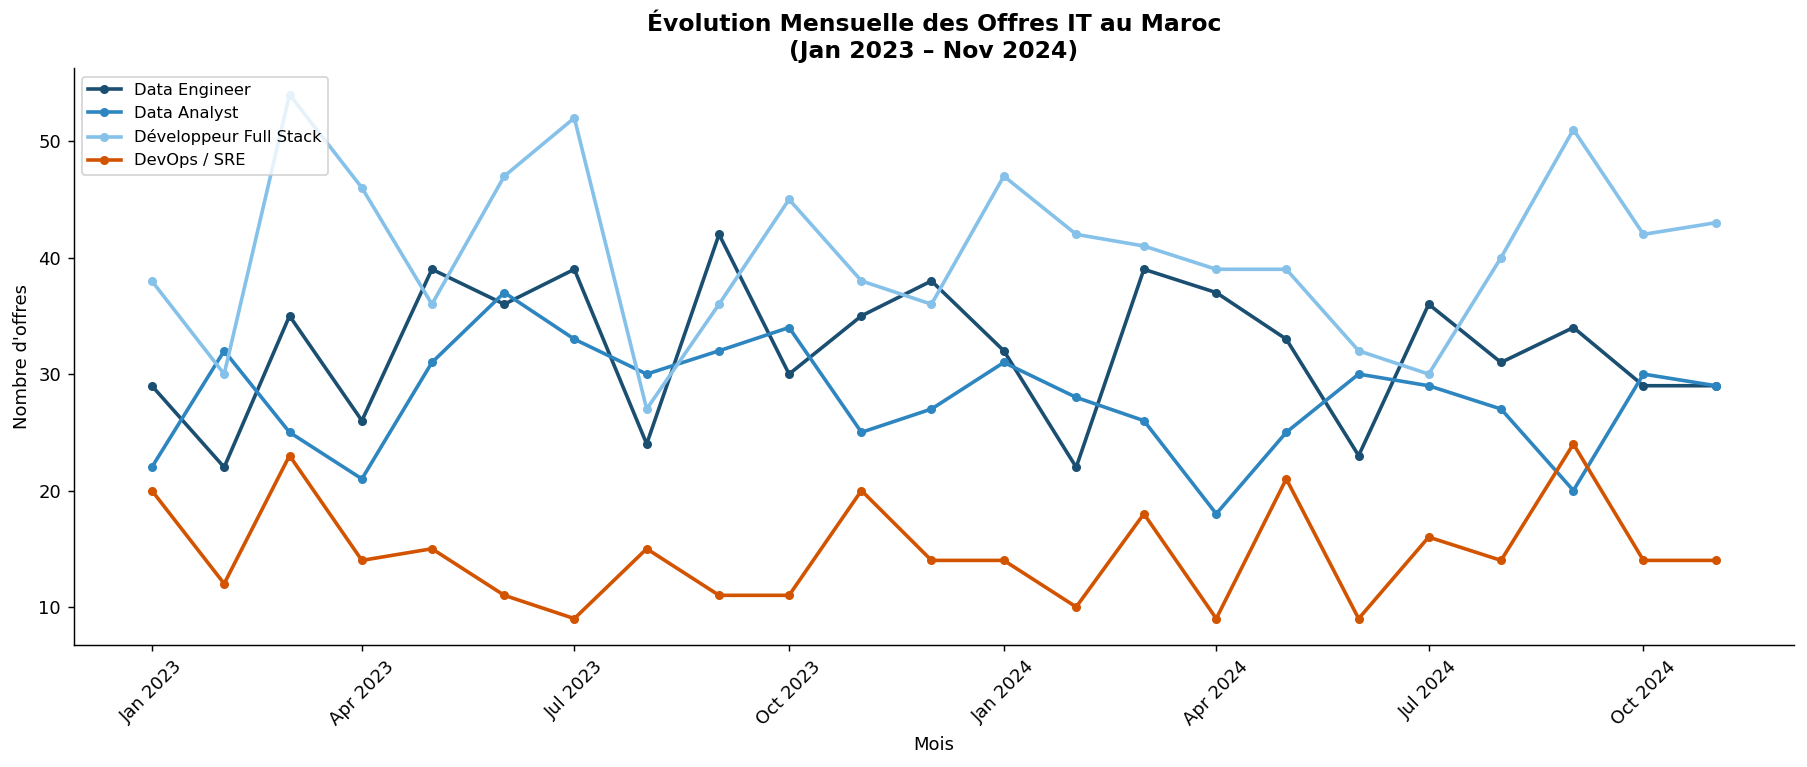


📊 Chart saved: tendances_mensuelles.png

✅  Analyse complète. 5 questions répondues, 5 visualisations produites.


In [16]:
# ── Tendances mensuelles ─────────────────────────────────────────────────────
q_tend = con.execute(f"""
    SELECT
        annee, mois,
        MAKE_DATE(annee::INT, mois::INT, 1) AS date_mois,
        profil,
        nb_offres
    FROM read_parquet('{GOLD}/tendances_mensuelles.parquet')
    WHERE profil IN ('Data Engineer','Data Analyst','Développeur Full Stack',
                     'DevOps / SRE')
    ORDER BY annee, mois
""").df()

q_tend['date_mois'] = pd.to_datetime(q_tend['date_mois'])

fig, ax = plt.subplots(figsize=(14, 6))
for idx, profil in enumerate(q_tend['profil'].unique()):
    sub = q_tend[q_tend['profil'] == profil].sort_values('date_mois')
    ax.plot(sub['date_mois'], sub['nb_offres'],
            marker='o', markersize=4, label=profil,
            color=COULEURS[idx], linewidth=2)

ax.set_xlabel("Mois")
ax.set_ylabel("Nombre d'offres")
ax.set_title("Évolution Mensuelle des Offres IT au Maroc\n(Jan 2023 – Nov 2024)")
ax.legend(loc='upper left', fontsize=9)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('tendances_mensuelles.png', bbox_inches='tight', dpi=130)
plt.show()
print("\n📊 Chart saved: tendances_mensuelles.png")
print("\n✅  Analyse complète. 5 questions répondues, 5 visualisations produites.")
